In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [5]:
import matplotlib.font_manager as fm
import platform

font_path='C:\Windows\Fonts\malgun.ttf' # 맑은 고딕 폰트 경로
font_prop=fm.FontProperties(fname=font_path)

In [24]:
df=pd.read_csv('./data/network_data.csv')

In [26]:
df

,고객ID,고객이름,동반인ID,주문메뉴
0,C0116,고객116,NaN,"['쫄면', '칼국수']"
1,C0169,고객169,NaN,"['순두부찌개', '된장찌개', '불고기']"
2,C0086,고객86,C0153,['쫄면']
3,C0104,고객104,C0163,"['순두부찌개', '된장찌개', '비빔밥']"
4,C0126,고객126,NaN,"['비빔밥', '김치찌개']"
...,...,...,...,...
995,C0082,고객82,NaN,"['쫄면', '칼국수']"
996,C0019,고객19,C0153,"['돈까스', '냉면', '불고기']"
997,C0003,고객3,NaN,['쫄면']
998,C0174,고객174,NaN,['비빔밥']


In [30]:
# 고객id: 고객 이름 매핑 딕셔너리 만들기
customer_dict = dict(zip(df['고객ID'], df['고객이름']))
customer_dict
companion_id=df['고객ID']
companion_name=df['고객이름']

In [38]:
# 고객 네트워크 그래프 생성
G=nx.Graph()

for idx, row in df.iterrows():
    print(idx,row)
    cust_id=row['고객ID']
    cust_name=row['고객이름']
    cust_label=f"{cust_name} ({cust_id})"
    print('1: ', cust_name)
    
    companion_id = row['동반인ID']
    if pd.notnull(companion_id):
        companion_name = customer_dict.get(companion_id,companion_id)
        companion_label=f"{companion_name} ({companion_id})"
        
        print(cust_label, companion_label)
        G.add_node(cust_label)
        G.add_node(companion_label)
        G.add_edge(cust_label, companion_label)
        


0 고객ID             C0116
고객이름             고객116
동반인ID              NaN
주문메뉴     ['쫄면', '칼국수']
Name: 0, dtype: object
1:  고객116
1 고객ID                        C0169
고객이름                        고객169
동반인ID                         NaN
주문메뉴     ['순두부찌개', '된장찌개', '불고기']
Name: 1, dtype: object
1:  고객169
2 고객ID      C0086
고객이름       고객86
동반인ID     C0153
주문메뉴     ['쫄면']
Name: 2, dtype: object
1:  고객86
고객86 (C0086) 고객153 (C0153)
3 고객ID                        C0104
고객이름                        고객104
동반인ID                       C0163
주문메뉴     ['순두부찌개', '된장찌개', '비빔밥']
Name: 3, dtype: object
1:  고객104
고객104 (C0104) 고객163 (C0163)
4 고객ID               C0126
고객이름               고객126
동반인ID                NaN
주문메뉴     ['비빔밥', '김치찌개']
Name: 4, dtype: object
1:  고객126
5 고객ID       C0184
고객이름       고객184
동반인ID      C0045
주문메뉴     ['돈까스']
Name: 5, dtype: object
1:  고객184
고객184 (C0184) 고객45 (C0045)
6 고객ID                C0181
고객이름                고객181
동반인ID                 NaN
주문메뉴     ['순두부찌개', '불고기']
Name: 6

578 고객ID      C0136
고객이름      고객136
동반인ID     C0078
주문메뉴     ['쫄면']
Name: 578, dtype: object
1:  고객136
고객136 (C0136) 고객78 (C0078)
579 고객ID            C0142
고객이름            고객142
동반인ID           C0191
주문메뉴     ['쫄면', '냉면']
Name: 579, dtype: object
1:  고객142
고객142 (C0142) 고객191 (C0191)
580 고객ID       C0069
고객이름        고객69
동반인ID        NaN
주문메뉴     ['불고기']
Name: 580, dtype: object
1:  고객69
581 고객ID                      C0065
고객이름                       고객65
동반인ID                     C0007
주문메뉴     ['비빔밥', '불고기', '된장찌개']
Name: 581, dtype: object
1:  고객65
고객65 (C0065) 고객7 (C0007)
582 고객ID                     C0096
고객이름                      고객96
동반인ID                    C0189
주문메뉴     ['비빔밥', '된장찌개', '냉면']
Name: 582, dtype: object
1:  고객96
고객96 (C0096) 고객189 (C0189)
583 고객ID        C0052
고객이름         고객52
동반인ID         NaN
주문메뉴     ['제육볶음']
Name: 583, dtype: object
1:  고객52
584 고객ID       C0118
고객이름       고객118
동반인ID      C0029
주문메뉴     ['칼국수']
Name: 584, dtype: object
1:  고객118
고객118 (C0118

In [39]:
# 중심성 분석
degree_centrality = nx.degree_centrality(G)
betweenness_centrality=nx.betweenness_centrality(G)
closeness_centrality=nx.closeness_centrality(G)



In [40]:
degree_centrality.items()

dict_items([('고객86 (C0086)', 0.020618556701030927), ('고객153 (C0153)', 0.041237113402061855), ('고객104 (C0104)', 0.02577319587628866), ('고객163 (C0163)', 0.041237113402061855), ('고객184 (C0184)', 0.02577319587628866), ('고객45 (C0045)', 0.02577319587628866), ('고객126 (C0126)', 0.010309278350515464), ('고객38 (C0038)', 0.015463917525773196), ('고객108 (C0108)', 0.010309278350515464), ('고객199 (C0199)', 0.030927835051546393), ('고객100 (C0100)', 0.041237113402061855), ('고객149 (C0149)', 0.02577319587628866), ('고객42 (C0042)', 0.02577319587628866), ('고객140 (C0140)', 0.02577319587628866), ('고객144 (C0144)', 0.015463917525773196), ('고객159 (C0159)', 0.015463917525773196), ('고객132 (C0132)', 0.010309278350515464), ('고객145 (C0145)', 0.030927835051546393), ('고객114 (C0114)', 0.041237113402061855), ('고객116 (C0116)', 0.030927835051546393), ('고객24 (C0024)', 0.03608247422680412), ('고객31 (C0031)', 0.020618556701030927), ('고객164 (C0164)', 0.010309278350515464), ('고객99 (C0099)', 0.030927835051546393), ('고객47 (C0047)', 0

In [41]:
# 상위 5명 정리
top_k=10
top_degree=sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:top_k]

result=[]
for node, degree in top_degree:
    result.append({
        "고객이름(고객ID)":node,
        "연결중심성(Degree)":round(degree,4),
        "매개중심성(Betweenness)":round(betweenness_centrality.get(node,0),4),
        "근접중심성(Closeness)" : round(closeness_centrality.get(node,0),4)
    })
    
df_result=pd.DataFrame(result)
df_result

,고객이름(고객ID),연결중심성(Degree),매개중심성(Betweenness),근접중심성(Closeness)
0,고객106 (C0106),0.0515,0.0713,0.3050
1,고객133 (C0133),0.0464,0.0645,0.3065
2,고객153 (C0153),0.0412,0.0440,0.2840
3,고객163 (C0163),0.0412,0.0366,0.2904
4,고객100 (C0100),0.0412,0.0531,0.2953
5,고객114 (C0114),0.0412,0.0517,0.2900
6,고객195 (C0195),0.0412,0.0707,0.3031
7,고객24 (C0024),0.0361,0.0412,0.2866
8,고객170 (C0170),0.0361,0.0331,0.2771
9,고객183 (C0183),0.0361,0.0375,0.2870


* 연결중심성(Degree) : 직접 연결된 고객 수 비율, 동만 방문 횟수나 연결된 고객이 많을수록 높음
* 매개중심성(Betweenness): 다른 고객 사이의 중개 역할 비율, 다양한 고객 집단을 이어주는 다리 역할을 할수록 높음
* 근접 중심성(Closeness): 전체 고객들과의 거리 평균의 역수, 네트워크 전체와 가깝게 연결되어 있을수록 높음

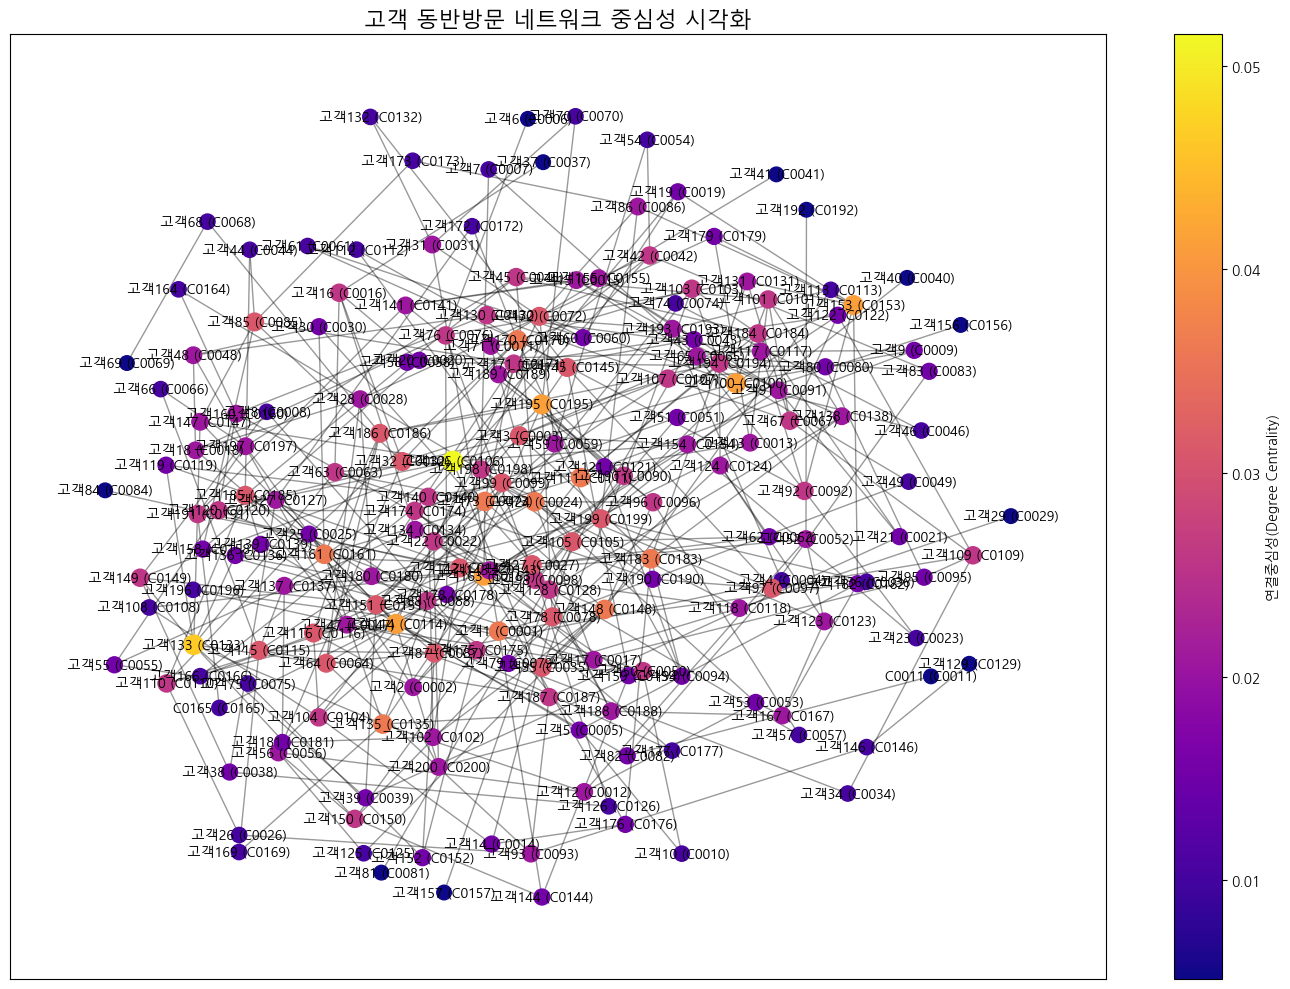

In [49]:
plt.rcParams['axes.unicode_minus']=False

# 노드 속성 설정
node_colors=[degree_centrality.get(node,0) for node in G.nodes]
node_sizes=[2000 * degree_centrality.get(node,0)+100 for node in G.nodes]

# 노드 위치 계산 k는 노드간의 평균거리(작으면 촘촘하게, 크면 넓게)
pos=nx.spring_layout(G,seed=42, k=0.5)

plt.figure(figsize=(14,10))
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=plt.cm.plasma)

# 엣지와 레이블
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=10, font_family=font_prop.get_name())
plt.colorbar(nodes, label='연결중심성(Degree Centrality)')
plt.title("고객 동반방문 네트워크 중심성 시각화", fontproperties=font_prop, fontsize=16)
plt.tight_layout()
plt.show()

In [45]:
dir(nx)

['AmbiguousSolution',
 'ArborescenceIterator',
 'DiGraph',
 'EdgePartition',
 'ExceededMaxIterations',
 'Graph',
 'GraphMLReader',
 'GraphMLWriter',
 'HasACycle',
 'LCF_graph',
 'LFR_benchmark_graph',
 'MultiDiGraph',
 'MultiGraph',
 'NetworkXAlgorithmError',
 'NetworkXError',
 'NetworkXException',
 'NetworkXNoCycle',
 'NetworkXNoPath',
 'NetworkXNotImplemented',
 'NetworkXPointlessConcept',
 'NetworkXTreewidthBoundExceeded',
 'NetworkXUnbounded',
 'NetworkXUnfeasible',
 'NodeNotFound',
 'NotATree',
 'PlanarEmbedding',
 'PowerIterationFailedConvergence',
 'SpanningTreeIterator',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_clear_cache',
 '_dispatchable',
 '_lazy_import',
 'adamic_adar_index',
 'add_cycle',
 'add_path',
 'add_star',
 'adjacency',
 'adjacency_data',
 'adjacency_graph',
 'adjacency_matrix',
 'adjacency_spectrum',
 'adjlist',
 'algebraic_connectivity',
 'algebraicconnectivi